In [1]:

%load_ext autoreload
%autoreload 2

import sys
import os
sys.path.append(os.path.abspath(".."))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from xgboost import XGBRegressor
from sklearn.linear_model import Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split

from src.utils import DEV_SET_CLEAN_PATH, COLS, print_model_metrics
from src.plots import plot_model_comparison

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# 2. Modelos base _con_ pipeline de preprocesamiento

Preparamos los pipelines

In [2]:
from src.config import linear_models_pipeline_config, decision_trees_pipeline_config
from src.pipeline import build_feature_pipeline, build_target_pipeline
from sklearn.compose import TransformedTargetRegressor

In [3]:
df_clean = pd.read_csv("../" + DEV_SET_CLEAN_PATH)
X = df_clean.drop(columns=[COLS.TARGET]) # excluimos estas columnas porque todavía no están preprocesadas!!!
y = df_clean[COLS.TARGET]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


]### 2.1 Lasso Regression

In [4]:
linear_feature_pipeline = build_feature_pipeline(linear_models_pipeline_config)
linear_target_pipeline = build_target_pipeline(linear_models_pipeline_config)

lasso_pipe_model = TransformedTargetRegressor(
    regressor=Lasso(alpha=10, random_state=42),
    transformer=linear_target_pipeline,
    check_inverse=False
)

full_lasso = Pipeline([
    ('preprocessor', linear_feature_pipeline),
    ('model', lasso_pipe_model)
])

full_lasso.fit(X_train, y_train)
y_pred_lasso = full_lasso.predict(X_test)
print_model_metrics(y_test, y_pred_lasso, "Lasso (Preprocesado)")


=== Modelo: Lasso (Preprocesado) ===
RMSE: 684768.2349
MAE: 78091.2856
R2: -0.0107
--------------------------------------------------


In [5]:
tree_feature_pipeline = build_feature_pipeline(decision_trees_pipeline_config)
tree_target_pipeline = build_target_pipeline(decision_trees_pipeline_config)

decision_tree = TransformedTargetRegressor(
    regressor=DecisionTreeRegressor(max_depth=4, random_state=42),
    transformer=tree_target_pipeline,
    check_inverse=False
)

full_tree = Pipeline([
    ('preprocessor', tree_feature_pipeline),
    ('model', decision_tree)
])

full_tree.fit(X_train, y_train)
y_pred_tree = full_tree.predict(X_test)
print_model_metrics(y_test, y_pred_tree, "Decision Tree (Preprocesado)")

=== Modelo: Decision Tree (Preprocesado) ===
RMSE: 609590.4795
MAE: 102975.3914
R2: 0.1991
--------------------------------------------------


In [6]:
xgb_regressor = TransformedTargetRegressor(
    regressor=XGBRegressor(n_estimators=500, learning_rate=0.1, max_depth=10, random_state=42, n_jobs=-1, enable_categorical=True, tree_method='hist'),
    transformer=tree_target_pipeline,
    check_inverse=False
)

full_xgb = Pipeline([
    ('preprocessor', tree_feature_pipeline),
    ('model', xgb_regressor)
])

full_xgb.fit(X_train, y_train)
y_pred_xgb = full_xgb.predict(X_test)
print_model_metrics(y_test, y_pred_xgb, "XGBoost (Preprocesado)")

=== Modelo: XGBoost (Preprocesado) ===
RMSE: 454466.0572
MAE: 65513.2593
R2: 0.5548
--------------------------------------------------


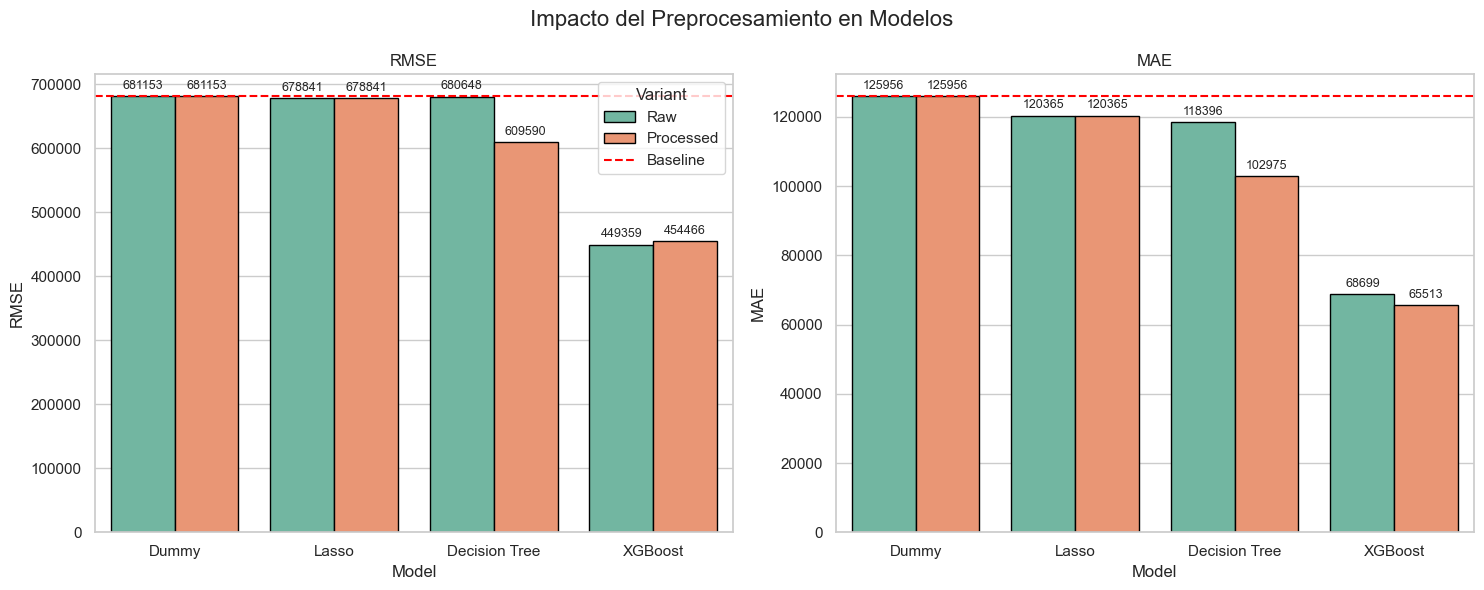

,Model,Variant,RMSE,MAE,R2,MAPE
0,Dummy,Raw,681152.912984,125955.554357,-0.000008,8.174219
1,Dummy,Processed,681152.912984,125955.554357,-0.000008,8.174219
2,Lasso,Raw,678841.101732,120364.548795,0.006768,6.571309
3,Lasso,Processed,678841.101732,120364.548795,0.006768,6.571309
4,Decision Tree,Raw,680648.205261,118395.757090,0.001473,6.123546
5,Decision Tree,Processed,609590.479528,102975.391379,0.199077,5.501625
6,XGBoost,Raw,449359.365190,68698.619399,0.564787,4.949633
7,XGBoost,Processed,454466.057249,65513.259269,0.554839,4.238287


In [7]:
# Cargamos predicciones de los modelos base para comparar
df_base_preds = pd.read_csv("../predictions/base_models.csv")
y_test_raw = df_base_preds['y_test'].values
y_pred_dummy = df_base_preds['Dummy'].values
y_pred_lasso_raw = df_base_preds['Lasso'].values
y_pred_tree_raw = df_base_preds['Decision Tree'].values
y_pred_xgb_raw = df_base_preds['XGBoost'].values

models_predictions = {
    'model': ['Dummy', 'Lasso', 'Decision Tree', 'XGBoost'],
    'y_pred': [y_pred_dummy, y_pred_lasso_raw, y_pred_tree_raw, y_pred_xgb_raw],
    'y_pred_processed': [y_pred_dummy, y_pred_lasso_raw, y_pred_tree, y_pred_xgb],
    'y_test': y_test_raw,
    'y_test_processed': y_test
}
plot_model_comparison(models_predictions)